# Preparing Data for a Regression Model

In this notebook, we will build a multiple regression model to predict daily average wind speed for Alamosa, Colorado. Our model will aim to predict wind speed from average temperature, pressure, relative humidity, maximum temperature, minimum temperature, precipitation and cloud cover. We want our predicted wind speed to be in miles per hour.

We will assess how good our model is by considering the r-squared value as well as residual and other plots.

To get the model to work, you need to perform some data processing. While you are figuring out what to do, bear in mind the following questions.

## Key Questions
- What are the data issues?
- How can you process the data to deal with these issues so that the model code runs?
- How does your decision on what to do affect the model parameters?

## Your Tasks
1. Run the code below to load the data into a `pandas` dataframe. Drop **all** columns **except** from the columns we will be using in the model.
2. Convert the wind speed column into miles per hour, from kilometers per hour.
3. Convert the dates to datetime objects.
4. Run the regression model code and figure out what is causing the error.
5. Look for missing values in the data set. Create a printout of the number of missing values in each column. Where exactly is the missing data?
6. Find a way to remove or replace the missing values so that the regression model works.
7. How good is the regression model? Is is better than the one we looked at before Spring break? What input parameters (x-values) could you drop without significantly reducing the explanatory power of the model?
8. If you tried more than one method to replace or remove missing values, which one do you think is better and why?

**Be prepared to give feedback on your work to the rest of the class.**

You may want to refer to the [Meteostat Python Library Guide](https://dev.meteostat.net/python) for notes on using this library.

Start by running the code below and identifying what the issues are.

### Import Data

This code imports the data from Meteostat and stores it in a dataframe called `alamosa`.

In [1]:
from datetime import date
import meteostat as ms, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Set display options for numpy
np.set_printoptions(floatmode='fixed', precision=3)

# Set start and end date for data
start = date(2025, 1, 1)
end = date(2025, 12, 31)

# Select Station(s)
alamosa_stn = ms.stations.meta(72462)

# Get data for three stations in CO
alamosa_data = ms.daily(alamosa_stn, start, end)
alamosa = alamosa_data.fetch()

# This code prints the entire dataset to help you locate where the missing data is.
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(alamosa)

            temp  tmin  tmax  rhum  prcp  snwd  wspd  wpgt    pres  tsun  cldc
time                                                                          
2025-01-01  -7.8 -17.1   2.2    63   0.0     0   4.7  <NA>  1026.2  <NA>     0
2025-01-02  -5.8 -14.9   9.4    59   0.0     0   6.8  <NA>  1029.2  <NA>     0
2025-01-03  -4.2 -14.3   9.4    63   0.0     0   4.7  <NA>  1028.6  <NA>     0
2025-01-04  -1.7 -12.1  10.0    53   0.0     0  19.8  <NA>  1013.0  <NA>     2
2025-01-05  -3.3 -13.2   4.4    52   0.0     0  11.9  <NA>  1019.6  <NA>     0
2025-01-06  -7.1 -16.0   1.1    59   0.0     0   5.0  <NA>  1025.5  <NA>     4
2025-01-07  -4.1 -10.5  -1.6    81   1.8     0   7.9  <NA>  1024.9  <NA>     8
2025-01-08  -9.6 -19.3  -0.5    76   0.0     5   4.7  <NA>  1030.3  <NA>     2
2025-01-09  -8.2 -14.9   0.0    63   0.0     0  14.4  <NA>  1021.8  <NA>     3
2025-01-10 -10.4 -21.0  -0.5    58   0.0     0   6.5  <NA>  1027.7  <NA>     0
2025-01-11  -9.1 -16.6  -0.5    60   0.0     0  10.8

### Print Out Count of Missing Data by Column

The code below should print out a count of how many `NaN` values there are in each column, along with the column name.

In [2]:
# Type your code here

for col_name, col_data in alamosa.items():
    print(f"Column: {col_name}, NaN Count: {col_data.isna().sum()}")

Column: temp, NaN Count: 0
Column: tmin, NaN Count: 0
Column: tmax, NaN Count: 0
Column: rhum, NaN Count: 0
Column: prcp, NaN Count: 0
Column: snwd, NaN Count: 0
Column: wspd, NaN Count: 0
Column: wpgt, NaN Count: 365
Column: pres, NaN Count: 4
Column: tsun, NaN Count: 365
Column: cldc, NaN Count: 4


### Process Data

The code below should drop unwanted columns, remove or replace missing data values, convert wind speed to miles per hour, and convert string dates to datetime objects.

In [3]:
# Type your code here

# Version where we drop missing values
alamosa.drop(columns=['wpgt', 'tsun'], inplace=True)
alamosa.dropna(inplace=True)
alamosa = alamosa.reset_index()
alamosa['time'] = pd.to_datetime(alamosa['time'])
alamosa['wspd'] = alamosa['wspd']*0.621371
alamosa

,time,temp,tmin,tmax,rhum,prcp,snwd,wspd,pres,cldc
0,2025-01-01,-7.8,-17.1,2.2,63,0.0,0,2.920444,1026.2,0
1,2025-01-02,-5.8,-14.9,9.4,59,0.0,0,4.225323,1029.2,0
2,2025-01-03,-4.2,-14.3,9.4,63,0.0,0,2.920444,1028.6,0
3,2025-01-04,-1.7,-12.1,10.0,53,0.0,0,12.303146,1013.0,2
4,2025-01-05,-3.3,-13.2,4.4,52,0.0,0,7.394315,1019.6,0
...,...,...,...,...,...,...,...,...,...,...
352,2025-12-27,3.4,-3.9,11.1,68,0.0,0,12.303146,1013.0,5
353,2025-12-28,-3.7,-14.4,3.3,50,0.0,0,9.444839,1020.2,1
354,2025-12-29,-7.4,-17.8,4.4,50,0.0,0,2.609758,1031.1,0
355,2025-12-30,-5.1,-16.7,7.8,53,0.0,0,2.423347,1031.1,1


In [ ]:
# Type your code here

# This version uses interpolation rather than dropping values
alamosa['pres'] = alamosa['pres'].interpolate()
alamosa['prcp'] = alamosa['prcp'].interpolate()
alamosa['cldc'] = alamosa['cldc'].interpolate()
alamosa.drop(columns=['wpgt', 'tsun'], inplace=True)
alamosa.dropna(inplace=True)
alamosa = alamosa.reset_index()
alamosa['time'] = pd.to_datetime(alamosa['time'])
alamosa

### Create Regression Model

The code below builds a model to predict wind speed based on the following inputs.

Inputs (`X`):
- Air Pressure (pres)
- Temperature (temp)
- Relative Humidity (rhum)
- Min temp (tmin)
- Max temp (tmax)
- Cloud cover (cldc)
- Precipitaiton (prcp)

Output (`y`):
- Wind Speed

The model uses the `LinearRegression` library from the `sklearn` package. This is a good library for multiple regression models.

The code will not work until you fix the issue with missing values.

In [4]:
# Build model using sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define independent variables (X) and the dependent variable (y)
X = alamosa[['temp', 'pres', 'rhum', 'tmin', 'tmax', 'prcp', 'cldc']] # Independent variables
y = alamosa['wspd']  # Single dependent variable


# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Make predictions and add them as a column in the dataframe
alamosa['Pred Wspd'] = model.predict(X)

# Print the coefficients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

# Evaluate the model (e.g., using r-squared score)
r_sq = model.score(X, y)
print(f"R-squared score: {r_sq:.4f}")

Coefficients: [-0.026 -0.225 -0.105  0.321 -0.293 -0.121  0.028]
Intercept: 247.9562338615067
R-squared score: 0.5674


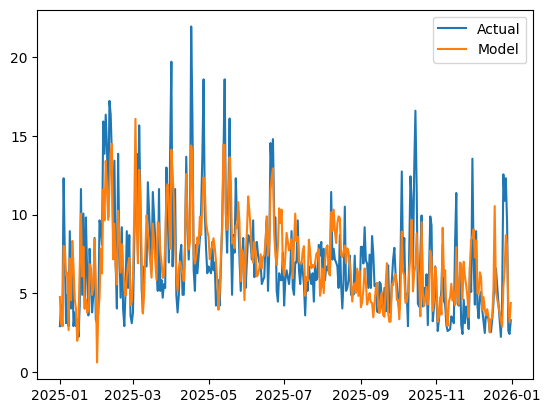

In [5]:
# Plot wind speed and predicted wind speed over time to compare
plt.plot(alamosa['time'], alamosa['wspd'], label='Actual')
plt.plot(alamosa['time'], alamosa['Pred Wspd'], label='Model')
plt.legend()
plt.show()

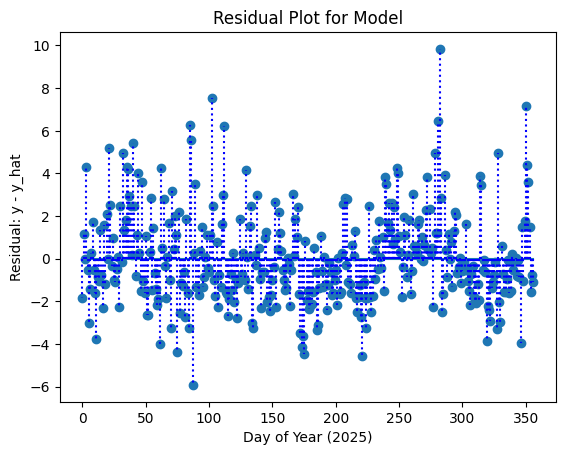

In [6]:
# Create and plot residuals
residuals = alamosa['wspd'] - alamosa['Pred Wspd']
x = np.arange(0, len(residuals))

# Plot residuals
plt.scatter(x, residuals)
plt.plot([x.min(), x.max()], [0,0])
for i in range(len(residuals)):
    plt.plot([x[i], x[i]], [0, residuals[i]], ':b')
plt.title("Residual Plot for Model")
plt.xlabel("Day of Year (2025)")
plt.ylabel("Residual: y - y_hat")
plt.show()

### Notes

Use this markdown cell to write any notes or comments.